# 2. The file holds 201 rows for 186 orders: which rows did the export count twice, and what makes two rows one order?

**Week 1, Wednesday. Chapter 2 of 6.** Chapter 1 profiled the export from the ERP, the enterprise resource planning system Finance books
orders in, counting what every field holds: 201 rows, 186 distinct order ids, one amount that does
not convert, and Q1 at
Rs 2,09,98,210 over the 200 amounts that do. This chapter decides what makes two rows one order,
which a dedupe, the step that removes repeated rows, has to know before it runs.

> **The client asks.** "Your dashboard says Q1 was Rs 2.1 crore. Our books say 1.9. Until your
> numbers match ours, Finance will not act on a drop measured from an ERP export. Send me a
> reconciliation."
>
> Anand Iyer, finance controller, Kalpa Retail

**Who needs the answer.** Anand Iyer, the finance controller, needs to know whether his books, Finance's own record of Q1 at
Rs 1,90,00,000 to the rupee, are short or the export is high. A wrong answer either keeps Rs 20 lakh
that was never earned or deletes real orders from his books, and every per-customer rate Tuesday
reported moves with the same rows, among them the 49 percent fall in orders per customer for
Retail-Plus, Kalpa's paid membership tier.

**The questions on the way.**

1. Which rules could decide that two rows are one order, and what does each flag here?
2. Where do rows outnumber orders?
3. Why does the default dedupe find no duplicates?
4. How many orders appear twice under the order id?
5. Does a rule that flags as many rows flag the same rows?
6. Does a count with no dictionary agree?

**The need.** The metrics at stake are Q1 revenue, Rs 2,09,98,210 as exported against
Rs 1,90,00,000 on the books, and the Q1 order count. The ERP team's note says the CSV was stitched
from two extracts, two separate pulls of rows out of the ERP, during the Q1 migration, the move of
the order data from one system to another. If orders were exported twice, Q1 revenue and the Q1
order count are both inflated, and so is every per-customer rate computed from them.

**Who else faces it.** On 22 and 23 May 2009 a processing fault at Starbucks billed some card customers twice across about 7,800 company-owned stores in the US and Canada, and the company repaid about one million customers (NBC News and AP, 10 June 2009, checked 30 Sep 2026). The same purchase recorded twice looks like two purchases until someone asks what makes two records one.

For more depth on the business behind these numbers, the retail dossier,
`content/W01/D1/study-notes/C2_W01_D01_domain_retail_STUDENT.md`, covers how the business makes money
in section 3, who decides what in section 4, and in section 5 the revenue tree, which writes revenue as
customers x orders per customer x revenue per order.

**Setup.** The cell loads the shared helper `kit` and chapter 1's tools. `read_orders()` reads the
export into dictionaries, one per row, each mapping a field's name to its value as text and keeping
the file line the row came from; `convert()` turns an amount into rupees or says why it could not;
and `profile()` counts each field's present, convertible and distinct values.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import csv, json, math
from collections import Counter
from datetime import date

DATA = kit.data_dir()
ORDERS_CSV = DATA / "C2_W01_D03_orders_STUDENT.csv"
BOOKS_Q1 = 19000000        # Anand's Q1 to the rupee, which his analyst sends on request

def read_orders(path=ORDERS_CSV):
    """Every row of an export as a dictionary of text, with the file line it came from."""
    with open(path, newline="", encoding="utf-8") as f:
        return [dict(row, line=n) for n, row in enumerate(csv.DictReader(f), start=2)]

def convert(value):
    """A whole number of rupees, or None with the reason, so a failure is counted, never hidden."""
    try:
        return int(value), ""
    except (TypeError, ValueError):
        return None, "amount does not convert to a whole number"

def Q(rows, quarter):
    """Rupees in a quarter over the amounts that convert."""
    return sum(convert(r["amount"])[0] or 0 for r in rows if r["quarter"] == quarter)

FIELDS = ["order_id", "customer_id", "segment", "channel", "city", "order_date", "amount",
          "status", "quarter", "discount"]
NUMERIC = {"amount", "discount"}

def profile(rows, fields=FIELDS):
    """Per field: present, convertible where the field is a number, and distinct."""
    out = {}
    for f in fields:
        present = [r.get(f, "") for r in rows if r.get(f, "") not in ("", None)]
        ok = [v for v in present if convert(v)[0] is not None] if f in NUMERIC else present
        out[f] = {"present": len(present), "convertible": len(ok), "distinct": len(set(present))}
    return out

raw = read_orders()
print(len(raw), "rows;", len({r["order_id"] for r in raw}), "distinct order ids")

201 rows; 186 distinct order ids


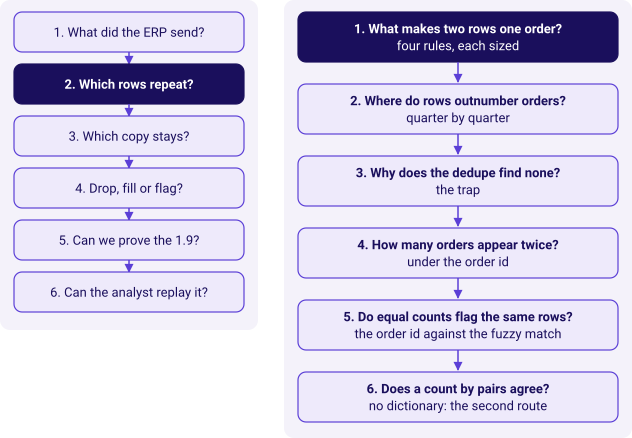

In [2]:
kit.side_by_side(
    kit.ladder(["What did the ERP send?", "Which rows repeat?", "Which copy stays?", "Drop, fill or flag?", "Can we prove the 1.9?", "Can the analyst replay it?"], lit=1, show=False),
    kit.vflow(["1. What makes two rows one order?\nfour rules, each sized", "2. Where do rows outnumber orders?\nquarter by quarter", "3. Why does the dedupe find none?\nthe trap", "4. How many orders appear twice?\nunder the order id", "5. Do equal counts flag the same rows?\nthe order id against the fuzzy match", "6. Does a count by pairs agree?\nno dictionary: the second route"], lit=0, show=False),
)

## 1. Which rules could decide that two rows are one order, and what does each flag here?

| Option | Two rows are the same when | Where it comes from |
|---|---|---|
| a) The whole record | every field matches, as the rows now stand | Most tools' default dedupe |
| b) The whole record less the line | every field but the file line matches | The first fix people reach for |
| c) The business key | `order_id` matches | The ERP issues one id per order |
| d) A fuzzy match | same customer and same amount, dated within 60 days | Record linkage, which matches records when no key can be trusted |

**Predict before you run.** Which options will flag the same number of rows as c? a) none;
b) only b; c) only d; d) b and d.

key,rows flagged,copies missed,real rupees removed,work
a) whole record,0,15,Rs 0,201 lookups
b) whole record less line,13,2,Rs 0,201 lookups
c) order_id,15,0,Rs 0,201 lookups
d) fuzzy match,15,1,"Rs 17,71,000","20,100 pairs"


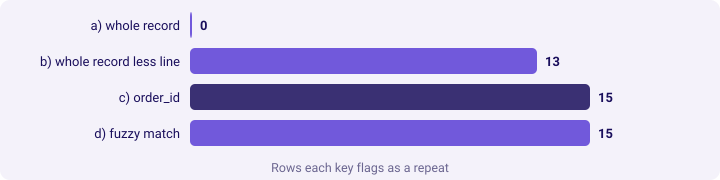

In [3]:
def flagged_by(rows, keyf):
    """The rows a key calls repeats; within a group the copy whose amount converts stays, as chapter 3 argues."""
    first, out = {}, []
    for r in rows:
        k = keyf(r)
        if k not in first:
            first[k] = r
        elif convert(first[k]["amount"])[0] is None and convert(r["amount"])[0] is not None:
            out.append(first[k]); first[k] = r
        else:
            out.append(r)
    return out

KEYS = {
    "a) whole record": lambda r: tuple(sorted(r.items())),
    "b) whole record less line": lambda r: tuple(sorted((k, v) for k, v in r.items() if k != "line")),
    "c) order_id": lambda r: r["order_id"],
}
by_key = {name: flagged_by(raw, f) for name, f in KEYS.items()}

def fuzzy_flagged(rows, days=60):
    """A fuzzy match: same customer, same amount, dates within `days`. No key to group on, so every pair is compared."""
    out, comparisons = {}, 0
    for i, a in enumerate(rows):
        for b in rows[i + 1:]:
            comparisons += 1
            if (a["customer_id"] == b["customer_id"] and a["amount"] == b["amount"] and
                    abs((date.fromisoformat(a["order_date"]) - date.fromisoformat(b["order_date"])).days) <= days):
                out[b["line"]] = b
    return list(out.values()), comparisons

by_key["d) fuzzy match"], comparisons = fuzzy_flagged(raw)
truth = {r["line"] for r in by_key["c) order_id"]}
rows_out = []
for name, flagged in by_key.items():
    lines = {r["line"] for r in flagged}
    wrong = [r for r in flagged if r["line"] not in truth]
    rows_out.append((name, len(flagged), len(truth - lines),
                     kit.rupees(sum(convert(r["amount"])[0] or 0 for r in wrong)),
                     f"{comparisons:,} pairs" if name.startswith("d") else "201 lookups"))
kit.table(["key", "rows flagged", "copies missed", "real rupees removed", "work"],
          rows_out, caption="Each key sized on the ERP file; 'copies missed' is measured against the order_id key")
kit.bars([(n, len(f)) for n, f in by_key.items()], lit=(2,), title="Rows each key flags as a repeat")

**What happened.** The answer is c: the fuzzy match flags 15 rows, as many as the order id, and they
are not the same 15. It removes one real order worth Rs 17,71,000 from the Business segment, Kalpa's
sales to companies, every order in lakhs, placed by a customer who spent the same amount again
within 60 days, and it misses a pair whose amounts differ. The whole record flags nothing, and the
whole record less the line flags 13 and misses two pairs. The fuzzy key also costs the most work:
without a key to group on, every row is compared with every other, 20,100 pairs here and about
200 lakh crore on a file of 2 crore rows.

**The best-fit call: c, the order id.** The ERP issues one id per order and never reuses it, so
the id is what the business says an order is, and the rule that says what makes two rows one order
is called the identity rule. **The fact that would change it:** two systems issuing their own ids,
the app numbering from one and the stores numbering from one. The id alone would then merge
different orders, and the key becomes the source system plus the id.

## 2. Where do rows outnumber orders?

**Predict before you run.** Where do rows and distinct ids part company? a) evenly; b) mostly in
Q1, the quarter of the migration; c) mostly in Q2; d) nowhere.

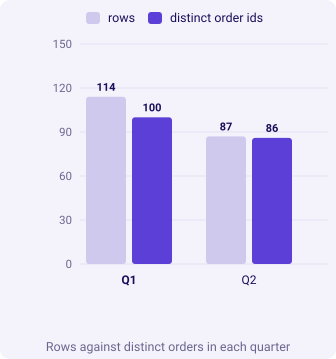

In [4]:
by_q = {}
for q in ("Q1", "Q2"):
    rows_q = [r for r in raw if r["quarter"] == q]
    by_q[q] = (len(rows_q), len({r["order_id"] for r in rows_q}))
kit.columns(["Q1", "Q2"], [("rows", [by_q["Q1"][0], by_q["Q2"][0]]),
                           ("distinct order ids", [by_q["Q1"][1], by_q["Q2"][1]])],
            lit=(0,), title="Rows against distinct orders in each quarter")
kit.check("Q1 carries 14 rows beyond one per order", by_q["Q1"][0] - by_q["Q1"][1] == 14)
kit.check("Q2 carries 1", by_q["Q2"][0] - by_q["Q2"][1] == 1)

**What happened.** The answer is b. Q1 holds 114 rows for 100 orders and Q2 holds 87 for 86, so the
extra rows sit in the quarter the migration touched, which is where the dashboard and the books
disagree. The first thing a hurried analyst reaches for is the default dedupe.

## 3. Why does the default dedupe find no duplicates?

Chapter 1 logged each amount that failed to convert with the file line it sat on, so `read_orders()`
gives every record a `line` field. A hurried analyst runs the default whole-record dedupe on those
records.

**The plausible wrong answer.**

In [5]:
def whole_record_dedupe(rows):
    seen, kept = set(), []
    for r in rows:
        key = tuple(sorted(r.items()))
        if key not in seen:
            seen.add(key)
            kept.append(r)
    return kept

kept_whole = whole_record_dedupe(raw)
kit.stats([(str(len(raw) - len(kept_whole)), "duplicates found", "the whole-record dedupe"),
           (kit.rupees(Q(kept_whole, "Q1")), "Q1 revenue", "unchanged, so the dashboard looks right"),
           ("Rs 20 lakh", "left unexplained", "and the note says Finance is short")],
          caption="The hurried dedupe, as it would be reported")

**Why it is wrong.** The file line records where a row sat and says nothing about which order it is.
Two copies of one order sit on different lines, so every record is unique and the dedupe can never
find anything. The note would tell Anand his books are Rs 20 lakh short, sending Finance to hunt for
revenue that was never earned. The check is chapter 1's count: 201 rows and 186 ids cannot both be
true of a file with no repeats. Five invented records, in which two orders appear twice, show the
mechanism:

In [6]:
# Invented records, to show the mechanism without touching the ERP file.
invented = [
    {"order_id": "INV-01", "segment": "Retail-Plus", "order_date": "2026-05-03", "amount": "2500"},
    {"order_id": "INV-02", "segment": "Retail-Core", "order_date": "2026-05-09", "amount": "1300"},
    {"order_id": "INV-01", "segment": "Retail-Plus", "order_date": "2026-05-03", "amount": "2500"},
    {"order_id": "INV-03", "segment": "Business", "order_date": "2026-06-11", "amount": "450000"},
    {"order_id": "INV-03", "segment": "Business", "order_date": "2026-06-11", "amount": "450000"},
]
for n, r in enumerate(invented, start=2):
    r["line"] = n

found = len(invented) - len(whole_record_dedupe(invented))
without_line = [{k: v for k, v in r.items() if k != "line"} for r in invented]
found_without = len(without_line) - len(whole_record_dedupe(without_line))
kit.table(["the comparison", "repeats found in the invented five"],
          [("every field, including the file line", found),
           ("every field except the file line", found_without),
           ("the order id alone", len(invented) - len({r["order_id"] for r in invented}))],
          caption="Invented records: the file line makes every row unique")
kit.check("the whole-record dedupe reports zero on the ERP file", len(raw) - len(kept_whole) == 0)
kit.check("yet distinct order ids fall 15 short of the rows", len(raw) - len({r["order_id"] for r in raw}) == 15)
kit.check("on invented records, leaving out the line finds both copies", found == 0 and found_without == 2)

the comparison,repeats found in the invented five
"every field, including the file line",0
every field except the file line,2
the order id alone,2


## 4. How many orders appear twice under the order id?

The fix groups the rows by the business key, `order_id`, and counts the groups that hold more than
one row.

**Predict before you run.** Grouped by `order_id`, how many groups hold more than one row? a) 14,
one per extra Q1 row; b) 15; c) 186; d) 201.

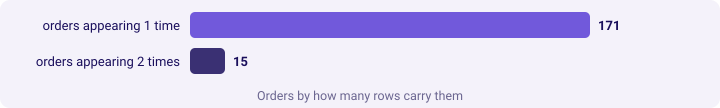

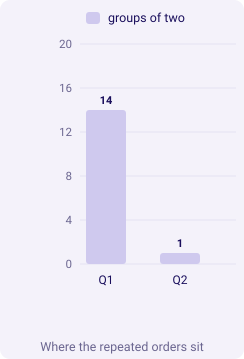

In [7]:
groups = {}
for r in raw:
    groups.setdefault(r["order_id"], []).append(r)
multi = {k: rs for k, rs in groups.items() if len(rs) > 1}
sizes = Counter(len(rs) for rs in groups.values())
kit.bars([(f"orders appearing {n} time{'s' if n > 1 else ''}", c) for n, c in sorted(sizes.items())],
         lit=(1,), title="Orders by how many rows carry them")
kit.columns(["Q1", "Q2"], [("groups of two", [sum(1 for rs in multi.values() if rs[0]["quarter"] == q) for q in ("Q1", "Q2")])],
            title="Where the repeated orders sit")
kit.check("15 orders appear twice, none three times", len(multi) == 15 and max(sizes) == 2)

**What happened.** The answer is b: 15 orders appear exactly twice, 14 in Q1 and one in Q2. Each
group of two is one order and a copy, and one row of each pair has to stay. Which one is chapter
3's question.

**Your turn.** In the empty cell, print the ids of the 15 orders and the file lines of both
copies, with `[(k, [r["line"] for r in rs]) for k, rs in multi.items()]`. Say what the second
line numbers have in common, and what that tells you about the migration.

## 5. Does a rule that flags as many rows flag the same rows?

**Predict before you run.** The fuzzy key flags 15 rows and the order id flags 15. How many rows do
the two sets share? a) 15; b) 14; c) 13; d) none.

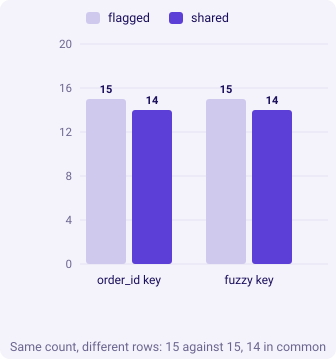

In [8]:
fuzzy = {r["line"] for r in by_key["d) fuzzy match"]}
shared = fuzzy & truth
kit.columns(["order_id key", "fuzzy key"], [("flagged", [len(truth), len(fuzzy)]), ("shared", [len(shared), len(shared)])],
            title="Same count, different rows: 15 against 15, 14 in common")
kit.check("the two keys share 14 of their 15 rows", len(shared) == 14, f"{len(shared)}")
kit.check("the fuzzy key removes a real order worth Rs 17,71,000",
          sum(convert(r["amount"])[0] or 0 for r in by_key["d) fuzzy match"] if r["line"] not in truth) == 1771000)

**What happened.** The answer is b. Equal counts do not mean the same rows: the two keys agree on 14
rows, and each flags one the other does not. A reviewer who compared counts would have signed off a
cleaning pass that removes Rs 17,71,000 of real Q2 revenue.

## 6. Does a count with no dictionary agree?

The groups found 15 rows beyond one per order by building a dictionary keyed on the id. A second
route that builds nothing compares every row with every row after it and counts the pairs that
share an order id; since no id sits on three rows, each such pair is one extra row.

In [9]:
pairs, compared = {"Q1": 0, "Q2": 0}, 0
for i, a in enumerate(raw):
    for b in raw[i + 1:]:
        compared += 1
        if a["order_id"] == b["order_id"]:
            pairs[b["quarter"]] += 1
grouped = sum(len(rs) - 1 for rs in groups.values())
kit.table(["route", "rows beyond one per order", "Q1", "Q2", "work"],
          [("groups by order_id", grouped, by_q["Q1"][0] - by_q["Q1"][1], by_q["Q2"][0] - by_q["Q2"][1], f"{len(raw)} lookups"),
           ("every row against every later row", sum(pairs.values()), pairs["Q1"], pairs["Q2"], f"{compared:,} comparisons")])
kit.check("both routes find 15 rows beyond one per order", sum(pairs.values()) == grouped == 15)
kit.check("and agree quarter by quarter", (pairs["Q1"], pairs["Q2"]) == (by_q["Q1"][0] - by_q["Q1"][1], by_q["Q2"][0] - by_q["Q2"][1]))

route,rows beyond one per order,Q1,Q2,work
groups by order_id,15,14,1,201 lookups
every row against every later row,15,14,1,"20,100 comparisons"


**When to switch.** The pairwise count needs no dictionary and no key to group on, so it is the
check to run when the grouping code is in doubt on a small file. Its cost grows with the square
of the rows, 20,100 comparisons here and about 200 lakh crore on 2 crore rows, so on anything large
the groups are the pass, and only they say which rows, which a log needs.

Kavya Nair, the senior analyst on the team, checks every number before it leaves.

> **Kavya's review.** "Tell me what makes two rows the same order before you tell me how many
> duplicates there are. Without an identity rule, a count of duplicates depends on whichever fields
> the tool happened to compare."

### In the interview: what makes two records the same, and which key fits a customer table merged from two apps?

**[F] How do you find duplicates, and what makes two records the same?** "I start by writing down
the identity rule. For an order that is the id the system issues; for a customer it might be a
normalised email, for a payment the gateway's reference. Then I count rows against distinct keys.
A whole-record comparison finds only exact copies, and a migration copy often differs somewhere: a
timestamp, a load id, a line number. Then I weigh them, since two rows can carry more money than a
hundred."

**[D] Design. Order id, whole record or fuzzy, for a customer table merged from two apps?** "Neither
app's id identifies a person across both, so the whole record and the id are out. I would
normalise email and phone and match on those, block by city so each record is compared only within
its own city, which keeps the comparisons in the thousands, and send every fuzzy match a person has
not confirmed to review. What would switch me back to a key is a shared customer id issued by one
system."

### Depth: what if the identity rule needs more than one field?

Customer id and order date together is a composite key; on this file it finds 14 of the 15,
because one pair's copies disagree on the date. Record linkage across systems starts the same
way, by writing down what makes two records one before counting anything.

## So which rows did the export count twice, and what makes two rows one order?

1. Of the four rules, the whole record flags 0 rows, the record less the line 13, the order_id 15
   and a fuzzy match 15 with a real Rs 17,71,000 order among them, so the order_id is the rule.
2. Rows outnumber orders in Q1, which holds 114 rows for 100 orders, while Q2 holds 87 for 86.
3. The default dedupe compares the file line too, so every row is unique: it finds 0, and Q1 stays
   at Rs 2,09,98,210.
4. Under the order id, 15 orders appear twice, 14 in Q1 and 1 in Q2, and none three times.
5. A rule that flags as many rows does not flag the same rows: the fuzzy match shares 14 of its 15
   rows with the order id and removes a real Rs 17,71,000 order.
6. A count with no dictionary agrees: every row against every later row finds 14 + 1 pairs, in
   20,100 comparisons.

The order_id is the identity, since the ERP issues one per order. Fifteen orders appear twice,
14 in Q1 and 1 in Q2, and none three times, so the export counted 15 orders twice.

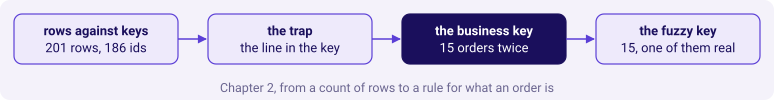

Next, chapter 3: when an order appears twice, which copy stays, and does Q1 then land on the books?


In [10]:
kit.flow(["rows against keys\n201 rows, 186 ids", "the trap\nthe line in the key",
          "the business key\n15 orders twice", "the fuzzy key\n15, one of them real"], lit=2,
         title="Chapter 2, from a count of rows to a rule for what an order is")
kit.check_summary()
print("Next, chapter 3: when an order appears twice, which copy stays, and does Q1 then land on the books?")